In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:

import json
student={
    "name": "Shyamashree",
    "age": 20,
    "department": "CSE",
    "semester": 5,
    "subject":["AI","Data Mining", "DBMS"]
}
with open("student.json","w") as file:
    json.dump(student, file, indent=4)



In [14]:
#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#Load the dataset
path="/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
iris=pd.read_csv(path)
#Display dataset information
print("Shape of the dataset:", iris.shape)
print("\nFirst 5 Rows:")
print(iris.head())

#Select Features (X) and Target sets
X=iris.iloc[:,1:5]
Y=iris["Species"]
#Split the dataset into Training and Testing Sets
X_train,X_test, y_train,y_test= train_test_split(
    X,Y,test_size=0.2,random_state= 42
) 
#Create the KNN model
knn =KNeighborsClassifier(n_neighbors=3)
#Train the model
knn.fit(X_train,y_train)
# Predict on test data
y_pred= knn.predict(X_test)
#Display results
print("\nPredicted Species:")
print(y_pred)
print("\nActual Species:")
print(y_test.values)
#Calculate Accuracy
accuracy= accuracy_score(y_test,y_pred)
print("\nAccuracy:", accuracy*100, "%")
#Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/organizations/uciml/iris/Iris.csv'

BFS Traversal: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


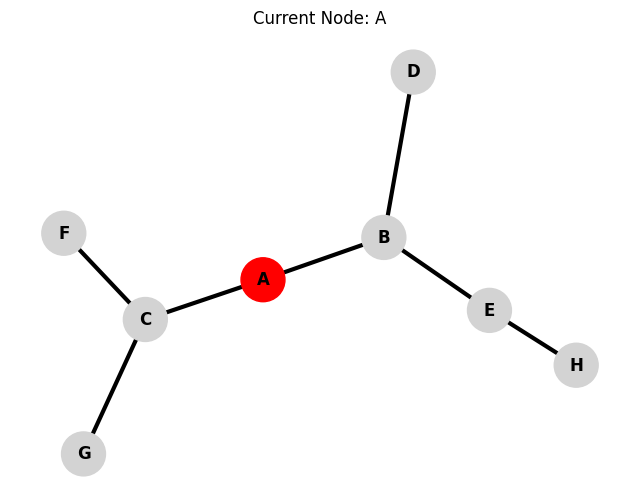

In [8]:
#write the python program to check bfs and dfs searching 
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import deque
from IPython.display import HTML

# Create graph
G = nx.Graph()

# Add edges
edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F'),
    ('C', 'G'),
    ('E', 'H')
]

G.add_edges_from(edges)
visited = []
parent = {}

queue = deque(['A'])   # Starting node

while queue:
    node = queue.popleft()

    if node not in visited:
        visited.append(node)

        for neighbour in sorted(G.neighbors(node)):
            if neighbour not in visited and neighbour not in queue:
                parent[neighbour] = node
                queue.append(neighbour)

print("BFS Traversal:", visited)

pos = nx.spring_layout(G, seed=5)

fig, ax = plt.subplots(figsize=(8, 6))
def update(frame):
    ax.clear()

    visited_now = visited[:frame + 1]

    node_colors = [
        'red' if node in visited_now else 'lightgray'
        for node in G.nodes()
    ]

    edge_colors = []

    for u, v in G.edges():
        if ((v in parent and parent[v] == u and v in visited_now) or
            (u in parent and parent[u] == v and u in visited_now)):
            edge_colors.append('green')
        else:
            edge_colors.append('black')

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1000,
        font_size=12,
        font_weight='bold',
        width=3
    )

    ax.set_title(f"Current Node: {visited[frame]}")
ani = FuncAnimation(
    fig,
    update,
    frames=len(visited),
    interval=1200,
    repeat=False
)

HTML(ani.to_jshtml())